In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("LHCb")

# B → Λc+ X and Missing Mass Technique

B mesons decay to charm baryons at ~6%.

Example:
B⁻ → Λc⁺ p̄ π⁻

These decays are difficult because:
- Multiple particles
- Some may be missing

## Missing Mass Method

We reconstruct Λc⁺ and compute:

M²_miss = (p_B − p_Λc)²

If Λc⁺ comes from a real B decay:
→ Missing mass corresponds to the unseen system X

## Connection to FEI

The Full Event Interpretation (FEI) reconstructs one B (tag-side).

This project extends that idea:
→ use Λc⁺ as a tagging handle

(arXiv:1807.08680)

In [2]:
np.random.seed(42)

N = 50000

# Constants (MeV)
M_B = 5279.3
M_Lc = 2286.5
Ecm = 10580.0

events = []

for _ in range(N):

    # Random X mass
    M_X = np.random.uniform(1000, 3000)

    # Two-body decay momentum
    p = np.sqrt(
        (M_B**2 - (M_Lc + M_X)**2) *
        (M_B**2 - (M_Lc - M_X)**2)
    ) / (2 * M_B)

    # Random direction
    theta = np.arccos(np.random.uniform(-1,1))
    phi = np.random.uniform(0, 2*np.pi)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    E_Lc = np.sqrt(p**2 + M_Lc**2)

    # Smearing (detector resolution)
    px += np.random.normal(0, 5)
    py += np.random.normal(0, 5)
    pz += np.random.normal(0, 5)

    # B at rest (approx in CM)
    E_B = Ecm / 2

    # Missing mass squared
    Mmiss2 = (E_B - E_Lc)**2 - (px**2 + py**2 + pz**2)

    events.append([px, py, pz, E_Lc, Mmiss2])

df_chain = pd.DataFrame(events, columns=[
    "px", "py", "pz", "E_Lc", "Mmiss2"
])

df_chain.to_csv("../data/B_to_Lc_chain.csv", index=False)

print("Generated B → Λc + X dataset")
df_chain.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_19932\1482221572.py:18: RuntimeWarning: invalid value encountered in sqrt
  p = np.sqrt(


Generated B → Λc + X dataset


,px,py,pz,E_Lc,Mmiss2
0,-88.305024,-726.668117,1527.517259,2845.056074,3.108597e+06
1,339.539904,-66.350617,-1147.151647,2581.907954,5.898116e+06
2,-498.842867,1374.485155,-1184.854602,2958.682931,1.893105e+06
3,-1168.067196,1301.110701,-795.512498,2979.872440,1.646579e+06
4,-1556.362544,-1024.121752,50.034445,2949.341497,2.005089e+06


In [3]:
# Background: random combinations
N_bkg = 50000

bkg = pd.DataFrame({
    "Mmiss2": np.random.uniform(0, 15e6, N_bkg)
})

df_chain["label"] = 1
bkg["label"] = 0

df_all = pd.concat([df_chain, bkg], ignore_index=True)

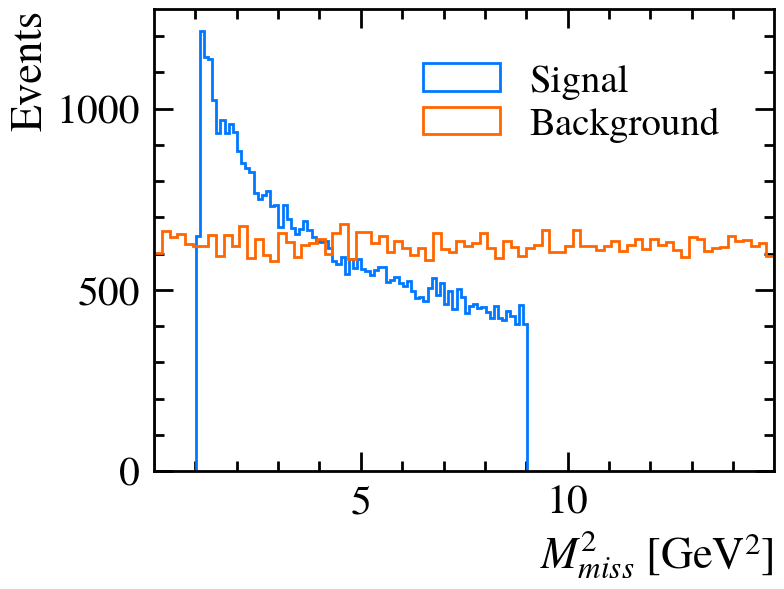

In [4]:
plt.figure(figsize=(8,6))

plt.hist(df_all[df_all["label"]==1]["Mmiss2"]/1e6,
         bins=80, histtype="step", label="Signal")

plt.hist(df_all[df_all["label"]==0]["Mmiss2"]/1e6,
         bins=80, histtype="step", label="Background")

plt.xlabel(r"$M^2_{miss}$ [GeV$^2$]")
plt.ylabel("Events")

plt.legend()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/missing_mass.png")
plt.show()

In [5]:
windows = [
    (0, 3),
    (3, 8),
    (8, 15)
]

for w in windows:
    subset = df_all[
        (df_all["Mmiss2"]/1e6 > w[0]) &
        (df_all["Mmiss2"]/1e6 < w[1]) &
        (df_all["label"] == 1)
    ]

    print(f"Window {w}: {len(subset)} signal events")

Window (0, 3): 17747 signal events
Window (3, 8): 27694 signal events
Window (8, 15): 4364 signal events


# Missing Mass Interpretation

The missing mass squared distribution reveals the structure of the 
unseen system X.

- Low M² → light systems
- High M² → multi-body or heavier states

In real Belle II analysis:
→ peaks correspond to specific decay modes

Example:
If M² ≈ M²(pπ) → X = pπ system

## Importance

This is the key method for:
- Partial reconstruction
- Tag-side identification
- FEI extension to baryonic modes

# Charm Baryon Tagging and FEI

Current FEI:
- Uses B → D(*) modes

Extension (this project):
- Include B → Λc+ X

Physics impact:
- ~6% of B decays are baryonic
- Even 10% reconstruction efficiency gives ~0.6% tagging gain

This directly improves:
- All Belle II measurements using B-tagging

This project demonstrates the feasibility of such an extension.